Code for analyzing model (CM2.5-FLOR, HighResMIP) and observed (ETOPO05) topography.

Relevant for manuscript Figure 1 and Supplemental Figures S1, S5

In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xesmf as xe
import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
from scipy.ndimage import gaussian_filter1d
import pyproj
os.environ["PROJ_DATA"] = pyproj.datadir.get_data_dir()
os.environ.setdefault("PROJ_LIB", os.environ["PROJ_DATA"])

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from shapely.ops import transform
from shapely.geometry import LineString

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm
import matplotlib.patheffects as pe
import cmocean
from cmocean import cm as cmo

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *
from domain_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar'

In [2]:
## +++ LOAD PRE-SET SUB-DOMAIN BOUNDARIES +++ ##
coords_map, regions = nam_regions()
domains = list(coords_map.keys())

In [3]:
### +++ IMPORT DATA +++ ###

# initialize dicts
flor = {}
hrmip = {}

# ETOPO05
etopo_full=xr.open_dataset(f'{dpath0}/topo_files/obs.etopo5.zsurf.nc').ROSE
etopo_full=etopo_full.rename({'ETOPO05_Y':'lat', 'ETOPO05_X':'lon'}) # rename dimensions 
etopo=etopo_full.where(etopo_full>0,np.nan)  # crudely remove bathymetry

# CM2.5-FLOR
flor_mask = xr.open_dataset(f'{dpath0}/FLOR/flor.land_mask.nc').LAND_MASK.rename({'lat':'GRID_YT', 'lon':'GRID_XT'})

flor['ctrl'] = xr.open_dataset(f'{dpath0}/topo_files/flor.ctrl.zsurf.nc').ZSURF.where(flor_mask>0.5,np.nan)
flor['ctrl'] = flor['ctrl'].rename({'GRID_YT':'lat', 'GRID_XT':'lon'})

flor['hicam'] = xr.open_dataset(f'{dpath0}/topo_files/flor.hicam.zsurf.nc').ZSURF.where(flor_mask>0.5,np.nan)
flor['hicam'] = flor['hicam'].rename({'GRID_YT':'lat', 'GRID_XT':'lon'})

flor['hitopo'] = xr.open_dataset(f'{dpath0}/topo_files/flor.hitopo.zsurf.nc').ZSURF.where(flor_mask>0.5,np.nan)
flor['hitopo'] = flor['hitopo'].rename({'GRID_YT':'lat', 'GRID_XT':'lon'})

flor['hicam-diff'] = flor['hicam'] - flor['ctrl']
flor['hitopo-diff'] = flor['hitopo'] - flor['ctrl']


In [4]:
### +++ INTERPOLATE OBSERVED TOPOGRAPHY TO IDEALIZED NOMINAL RESOLUTIONS +++ ###

# --- define etopo source grid --- #
lat_fine = etopo.lat
lon_fine = etopo.lon
# add bounds to source grid
dlat_fine = float(lat_fine[1] - lat_fine[0])
dlon_fine = float(lon_fine[1] - lon_fine[0])
etopo_src = etopo.to_dataset(name='topo')
etopo_src['lat_b'] = xr.DataArray(
      np.append(lat_fine.values - dlat_fine/2, lat_fine.values[-1] + dlat_fine/2),
      dims=['lat_b']
)
etopo_src['lon_b'] = xr.DataArray(
    np.append(lon_fine.values - dlon_fine/2, lon_fine.values[-1] + dlon_fine/2),
    dims=['lon_b']
)


# --- construct coarse target grids, then map etopo05 data to target grids --- #
lat_coarse = {}
lon_coarse = {}
etopo_coarse = {}

# approximate resolution and number of degrees corresponding to each grid-cell
# --> 50 km ~ 0.5°, 100 km ~ 1°, 125 km ~ 1.25°, 200 km ~ 2°
resolutions = ['50km', '100km', '125km', '200km']
grid_spc_deg = [0.5, 1.0, 1.25, 2.0]

for res,deg in zip(resolutions, grid_spc_deg):

    # coarse grid
    lat_coarse[res] = np.arange(lat_fine.min(), lat_fine.max()+0.01, deg)
    lon_coarse[res] = np.arange(lon_fine.min(), lon_fine.max()+0.01, deg)
    dlat = lat_coarse[res][1] - lat_coarse[res][0]
    dlon = lon_coarse[res][1] - lon_coarse[res][0]
    # grid bounds
    coarse_lat_b = np.append(lat_coarse[res] - dlat/2, lat_coarse[res][-1] + dlat/2)
    coarse_lon_b = np.append(lon_coarse[res] - dlon/2, lon_coarse[res][-1] + dlon/2)
    
    coarse_grid = xr.Dataset({
        'lat':   (['lat'],   lat_coarse[res]),
        'lon':   (['lon'],   lon_coarse[res]),
        'lat_b': (['lat_b'], coarse_lat_b),
        'lon_b': (['lon_b'], coarse_lon_b),
    })

    regridder = xe.Regridder(etopo_src, coarse_grid, method='conservative', periodic=True)
    etopo_coarse[res] = regridder(etopo_src['topo'], skipna=True, na_thres=0.75)

# --- get idealized topographic BC for median HighResMIP resolutions --- #
hrmip = {}
hrmip['low'] = etopo_coarse['125km']
hrmip['high'] = etopo_coarse['50km']

## Figure comparing ETOPO05 and model topographies and zonal maximum profiles

In [5]:
# calculate meridional maximum surface height for longitudinal transect spanning Baja Peninsula & Central Mexico

# set lat/lon bounds
ymin, ymax = 24, 29
xmin, xmax = 245.5, 265

# extract topography
topo_profile = {}
topo_profile['etopo']  = etopo.sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
topo_profile['ctrl']   = flor['ctrl'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
topo_profile['hicam']  = flor['hicam'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
topo_profile['hitopo'] = flor['hitopo'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
topo_profile['hrmip-low'] = hrmip['low'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
topo_profile['hrmip-hi'] = hrmip['high'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)

In [6]:
# calculate meridional maximum surface height for longitudinal transect spanning SW U.S./Mexico Border region

# set lat/lon bounds
ymin, ymax = 31.5, 33.5
xmin, xmax = 242, 260

# extract topography
northern_topo_profile = {}
northern_topo_profile['etopo']  = etopo.sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
northern_topo_profile['ctrl']   = flor['ctrl'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
northern_topo_profile['hicam']  = flor['hicam'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
northern_topo_profile['hitopo'] = flor['hitopo'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
northern_topo_profile['hrmip-low'] = hrmip['low'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)
northern_topo_profile['hrmip-hi'] = hrmip['high'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax)).max(dim="lat",skipna=True)

In [17]:
# subset topo fields close to map bounds to reduce file size

# set lat/lon bounds
ymin, ymax = 14, 41
xmin, xmax = 239, 271

# extract topography
topo_subset = {}
topo_subset['etopo']  = etopo.sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
for res in resolutions:
    topo_subset[res] = etopo_coarse[res].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['ctrl']   = flor['ctrl'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hicam']  = flor['hicam'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hitopo'] = flor['hitopo'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hicam-diff']  = flor['hicam-diff'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hitopo-diff'] = flor['hitopo-diff'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hrmip-low'] = hrmip['low'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))
topo_subset['hrmip-hi'] = hrmip['high'].sel(lat=slice(ymin,ymax), lon=slice(xmin,xmax))

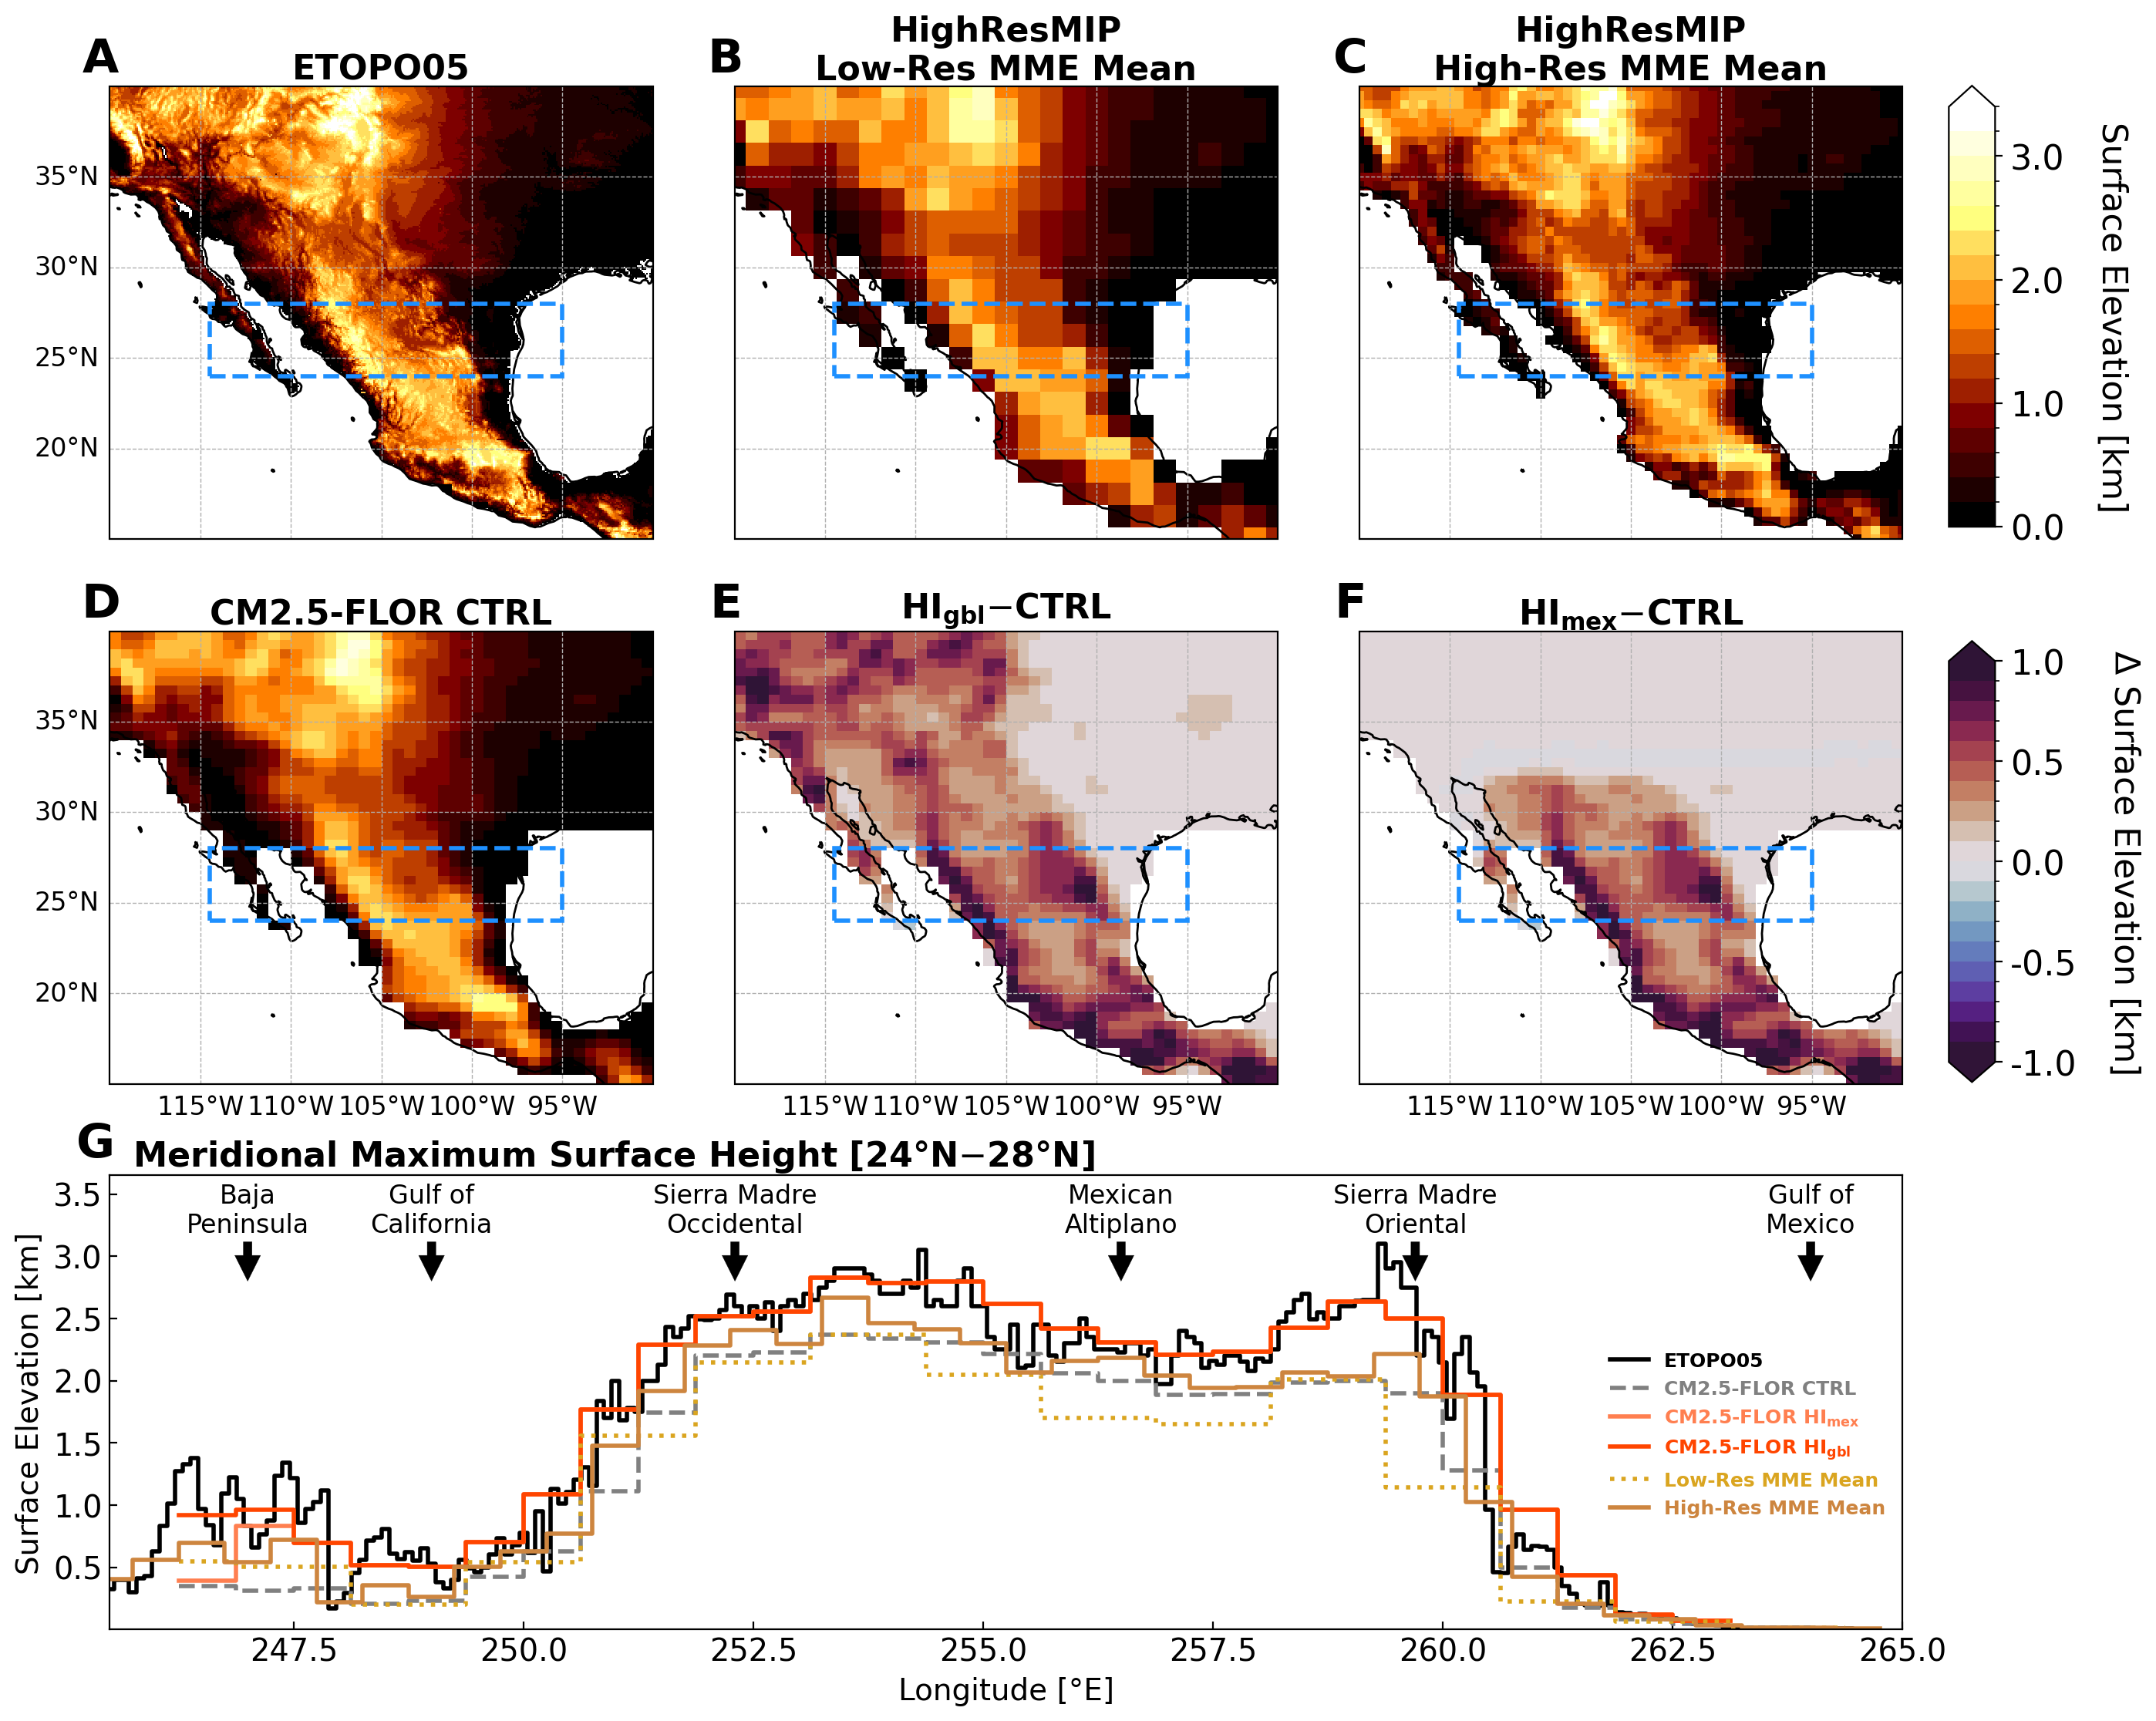

In [8]:
# --- settings --- #
# label specs
text_kw={'size':16, 'weight':'bold', 'color':'k', 'ha':'left', 'va':'center'}
text_kw1={'size':16, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'bottom'}
text_kw2={'size':22, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
labels=['ETOPO05',
        'CM2.5-FLOR CTRL',
        r'CM2.5-FLOR HI$\mathbf{_{mex}}$',
        r'CM2.5-FLOR HI$\mathbf{_{gbl}}$',
        'Low-Res MME Mean',
        'High-Res MME Mean']
titles=['ETOPO05',
        'HighResMIP\nLow-Res MME Mean',
        'HighResMIP\nHigh-Res MME Mean',
        'CM2.5-FLOR CTRL',
        r'HI$\mathbf{_{gbl}}$$-$CTRL',
        r'HI$\mathbf{_{mex}}$$-$CTRL']
letters=['A','B','C','D','E','F','G','H','I','J']
tx=-105
ty=40
# patch specs
patch_kw = {'ec':'dodgerblue', 'lw':2, 'ls':'--', 'fc':'none', 'clip_on':False, 'zorder':100}
# for line plot
tkw = {'axis': 'both', 'direction':'in', 'labelsize': 'x-large'} 
arrow_kw=dict(color='black', linewidth=.15, shrink=0)
arrow_text_kw={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'bottom'}
legend_prop={'size':9, 'weight':'bold'}
legend_kw={'loc':'upper right', 'bbox_to_anchor':(1, .65), 'labelcolor':'linecolor', 'ncols':1, 'frameon':False}
colors=['k','grey','coral','orangered','goldenrod','peru']
steploc='mid'
# colormap | topo field
cmap=cm.afmhot
vmin=0
vmax=3400
levels=np.linspace(vmin, vmax, 18)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
# colormap | topo difference
dcmap=cm.twilight_shifted
dvmin=-1000
dvmax=1000
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[-120., -90., 15., 40.]


fig = plt.figure(figsize=(15, 13))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.2, wspace=0.15)
axes = []

# --- topography maps --- #
for i,key in enumerate(['etopo','hrmip-low','hrmip-hi']):
    ax = fig.add_subplot(gs[0, i], projection=proj)
    cf = ax.pcolormesh(topo_subset[key].lon, topo_subset[key].lat, topo_subset[key], cmap=cmap, norm=norm, shading='auto', transform=trans)
    axes.append(ax)
    
ax = fig.add_subplot(gs[1, 0], projection=proj)
ax.pcolormesh(topo_subset['ctrl'].lon, topo_subset['ctrl'].lat, topo_subset['ctrl'], cmap=cmap, norm=norm, shading='auto', transform=trans)
axes.append(ax)

for i,key in enumerate(['hitopo-diff','hicam-diff']):
    ax = fig.add_subplot(gs[1, i+1], projection=proj)
    cf2 = ax.pcolormesh(topo_subset[key].lon, topo_subset[key].lat, topo_subset[key], cmap=dcmap, norm=dnorm, shading='auto', transform=trans)
    axes.append(ax)
    
for i, ax in enumerate(axes):
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw1)
    ax.text(-120.5,ty+1.5,letters[i], **text_kw2, zorder=100)
    # add box around region of topographic profile
    pp=plt.Rectangle((-114.5, 24), 19.5, 4, label='_Hidden', **patch_kw) 
    ax.add_patch(pp)
    # map properties
    ax.coastlines(color='k')
    #ax.add_feature(cfeature.OCEAN, fc='w', zorder=10)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=(i in [3,4,5]); gl.left_labels=(i in [0,3]); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LongitudeFormatter()
    gl.yformatter=LatitudeFormatter()
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}

# add colorbars
cax=fig.add_axes([.92, .66, 0.02, 0.22])
cbar=fig.colorbar(cf, orientation='vertical', extend='max', cax=cax)
cbar.set_ticks([0,1000,2000,3000])
cbar.set_ticklabels([0.0,1.0,2.0,3.0])
cbar.set_label('Surface Elevation [km]', labelpad=30, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontweight('normal')
    
cax=fig.add_axes([.92, .383, 0.02, 0.22])
cbar=fig.colorbar(cf2, orientation='vertical', extend='both', cax=cax)
cbar.set_ticks([-1000, -500, 0, 500, 1000])
cbar.set_ticklabels([-1.0, -0.5 ,0.0, 0.5, 1.0])
cbar.set_label('$\Delta$ Surface Elevation [km]', labelpad=30, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontweight('normal')
    
    
# --- topography profiles --- #
# Baja Peninsula/Central Mexico
ax7 = fig.add_subplot(gs[2, :])
ax7.text(245.75, 3800, f'Meridional Maximum Surface Height [24°N$-$28°N]', rotation=0, **text_kw)
ax7.text(245.35, 3900, letters[6], **text_kw2)

for i,(case,profile) in enumerate(topo_profile.items()):
    lcol = colors[i]
    if case in ['ctrl']:
        ls='--'
    elif case in ['hrmip-low']:
        ls='dotted'
    else:
        ls='-'
    ax7.step(topo_profile[case].lon, profile, where=steploc, color=lcol, lw=2, ls=ls, label=labels[i])

ty1, ty2 = 2800, 3150
ax7.annotate('Baja\nPeninsula', xy=(247,ty1), xytext=(247,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Gulf of\nCalifornia', xy=(249,ty1), xytext=(249,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Sierra Madre\nOccidental', xy=(252.3,ty1), xytext=(252.3,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Mexican\nAltiplano', xy=(256.5,ty1), xytext=(256.5,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Sierra Madre\nOriental', xy=(259.7,ty1), xytext=(259.7,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Gulf of\nMexico', xy=(264,ty1), xytext=(264,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)

ax7.set(xlim=[245.5, 265], ylim=[0,3650])
ax7.set_ylabel('Surface Elevation [km]', fontsize=14, fontweight='normal')
ax7.yaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax7.set_xlabel('Longitude [°E]', fontsize=14, fontweight='normal')
ax7.xaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax7.set_yticks([500,1000,1500,2000,2500,3000,3500])
ax7.set_yticklabels([0.5,1.0,1.5,2.0,2.5,3.0,3.5])
ax7.tick_params(**tkw)
ax7.legend(prop=legend_prop, **legend_kw)

#plt.savefig('../figs/topo_swna_maps_profiles_etopo_hrmip-median_gfdl.png', transparent=True, bbox_inches='tight')
#plt.savefig('../figs/topo_swna_maps_profiles_etopo_hrmip-median_gfdl.pdf', transparent=True, bbox_inches='tight')

#### deprecated version with CMCC topo

In [ ]:
# --- settings ---
# label specs
text_kw={'size':16, 'weight':'bold', 'color':'k', 'ha':'left', 'va':'center'}
text_kw1={'size':16, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'bottom'}
text_kw2={'size':22, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
labels=['ETOPO05',
        'CM2.5-FLOR CTRL',
        r'CM2.5-FLOR HI$\mathbf{_{mex}}$',
        r'CM2.5-FLOR HI$\mathbf{_{gbl}}$',
        'CMCC-CM2-HR4',
        'CMCC-CM2-VHR4']
titles=['ETOPO05',
        'CMCC-CM2-HR4',
        'CMCC-CM2-VHR4',
        'CM2.5-FLOR CTRL',
        r'HI$\mathbf{_{gbl}}$$-$CTRL',
        r'HI$\mathbf{_{mex}}$$-$CTRL']
letters=['A','B','C','D','E','F','G','H','I','J']
tx=-105
ty=40
# patch specs
patch_kw = {'ec':'dodgerblue', 'lw':2, 'ls':'--', 'fc':'none', 'clip_on':False, 'zorder':100}
# for line plot
tkw = {'axis': 'both', 'direction':'in', 'labelsize': 'x-large'} 
arrow_kw=dict(color='black', linewidth=.15, shrink=0)
arrow_text_kw={'size':12, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'bottom'}
legend_prop={'size':9, 'weight':'bold'}
legend_kw={'loc':'upper right', 'bbox_to_anchor':(1, .95),
           'labelcolor':'linecolor', 'ncols':1, 'frameon':False}
colors=['k','grey','coral','orangered','goldenrod','peru']
steploc='mid'
# colormap | topo field
cmap=cm.afmhot
vmin=0
vmax=3400
levels=np.linspace(vmin, vmax, 18)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
# colormap | topo difference
dcmap=cm.twilight_shifted
dvmin=-1000
dvmax=1000
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[-120., -90., 15., 40.]


fig = plt.figure(figsize=(15, 18))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.2, wspace=0.25)

# map subplots
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax1.pcolormesh(etopo.lon, etopo.lat, etopo, cmap=cmap, norm=norm, shading='auto', transform=trans)

ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax2.pcolormesh(hrmip['low'].lon, hrmip['low'].lat, hrmip['low'], cmap=cmap, norm=norm, shading='auto', transform=trans)

ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax3.pcolormesh(hrmip['high'].lon, hrmip['high'].lat, hrmip['high'], cmap=cmap, norm=norm, shading='auto', transform=trans)

ax4 = fig.add_subplot(gs[1, 0], projection=proj)
cf=ax4.pcolormesh(flor['ctrl'].lon, flor['ctrl'].lat, flor['ctrl'], cmap=cmap, norm=norm, shading='auto', transform=trans)

ax5 = fig.add_subplot(gs[1, 1], projection=proj)
ax5.pcolormesh(flor['hitopo'].lon, flor['hitopo'].lat, flor['hitopo-diff'], cmap=dcmap, norm=dnorm, shading='auto', transform=trans)

ax6 = fig.add_subplot(gs[1, 2], projection=proj)
cf2=ax6.pcolormesh(flor['hicam'].lon, flor['hicam'].lat, flor['hicam-diff'], cmap=dcmap, norm=dnorm, shading='auto', transform=trans)


for i,ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6]):
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw1)
    ax.text(-120.5,ty+1.5,letters[i], **text_kw2, zorder=100)
    # add box around region of topographic profile
    pp2=plt.Rectangle((-119, 31.5), 19, 2, label='_Hidden', **patch_kw) 
    ax.add_patch(pp2)
    pp=plt.Rectangle((-115, 24), 20, 4, label='_Hidden', **patch_kw) 
    ax.add_patch(pp)
    # map properties
    ax.coastlines(color='k')
    #ax.add_feature(cfeature.OCEAN, fc='w', zorder=10)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LongitudeFormatter()
    gl.yformatter=LatitudeFormatter()
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}

# add colorbars
cax=fig.add_axes([.92, .725, 0.02, 0.15])
cbar=fig.colorbar(cf, orientation='vertical', extend='max', cax=cax)
cbar.set_ticks([0,1000,2000,3000])
cbar.set_ticklabels([0.0,1.0,2.0,3.0])
cbar.set_label('Surface Elevation [km]', labelpad=30, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontweight('normal')
    
cax=fig.add_axes([.92, .52, 0.02, 0.15])
cbar=fig.colorbar(cf2, orientation='vertical', extend='both', cax=cax)
cbar.set_ticks([-1000, -500, 0, 500, 1000])
cbar.set_ticklabels([-1.0, -0.5 ,0.0, 0.5, 1.0])
cbar.set_label('$\Delta$ Surface Elevation [km]', labelpad=30, rotation=270, size=16, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label1.set_fontweight('normal')
    
    

# --- topography profiles ---

# SW U.S./Mexico Border (northern)
ax7 = fig.add_subplot(gs[2, :])
ax7.text(241.5, 3350, f'Meridional Maximum Surface Height [31.5°N$-$33.5°N]', rotation=0, **text_kw)
ax7.text(240.75, 3400, letters[6], **text_kw2)

for i,(case,profile) in enumerate(northern_topo_profile.items()):
    lcol = colors[i]
    if case in ['ctrl']:
        ls='--'
    elif case in ['hrmip-low']:
        ls='dotted'
    else:
        ls='-'
    ax7.step(northern_topo_profile[case].lon, profile, where=steploc, color=lcol, lw=2, ls=ls, label=labels[i])

ty1, ty2 = 2500, 2800
ax7.annotate('Pacific\nOcean', xy=(242,ty1), xytext=(242,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Baja\nPeninsula', xy=(243.75,ty1), xytext=(243.75,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Low\nDeserts', xy=(246,ty1), xytext=(246,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax7.annotate('Sierra Madre\nOccidental', xy=(250,ty1), xytext=(250,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)

ax7.set(xlim=[241, 260], ylim=[0,3250])
ax7.set_ylabel('Surface Elevation [km]', fontsize=14, fontweight='normal')
ax7.yaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax7.xaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax7.set_yticks([500,1000,1500,2000,2500,3000])
ax7.set_yticklabels([0.5,1.0,1.5,2.0,2.5,3.0])
ax7.tick_params(**tkw)
ax7.legend(prop=legend_prop, **legend_kw)

# Baja Peninsula/Central Mexico
ax8 = fig.add_subplot(gs[3, :])
ax8.text(245.5, 3750, f'Meridional Maximum Surface Height [24°N$-$28°N]', rotation=0, **text_kw)
ax8.text(244.75, 3800, letters[7], **text_kw2)

for i,(case,profile) in enumerate(topo_profile.items()):
    lcol = colors[i]
    if case in ['ctrl']:
        ls='--'
    elif case in ['hrmip-low']:
        ls='dotted'
    else:
        ls='-'
    ax8.step(topo_profile[case].lon, profile, where=steploc, color=lcol, lw=2, ls=ls, label=labels[i])

ty1, ty2 = 2800, 3150
ax8.annotate('Pacific\nOcean', xy=(245.5,ty1), xytext=(245.5,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Baja\nPeninsula', xy=(247,ty1), xytext=(247,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Gulf of\nCalifornia', xy=(249,ty1), xytext=(249,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Sierra Madre\nOccidental', xy=(252.3,ty1), xytext=(252.3,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Mexican\nAltiplano', xy=(256.5,ty1), xytext=(256.5,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Sierra Madre\nOriental', xy=(259.7,ty1), xytext=(259.7,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)
ax8.annotate('Gulf of\nMexico', xy=(264,ty1), xytext=(264,ty2), label='_Hidden', arrowprops=arrow_kw, **arrow_text_kw)

ax8.set(xlim=[245, 265], ylim=[0,3650])
ax8.set_ylabel('Surface Elevation [km]', fontsize=14, fontweight='normal')
ax8.yaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax8.set_xlabel('Longitude [°E]', fontsize=14, fontweight='normal')
ax8.xaxis.set_tick_params(labelsize='x-large', color='k', labelcolor='k')
ax8.set_yticks([500,1000,1500,2000,2500,3000,3500])
ax8.set_yticklabels([0.5,1.0,1.5,2.0,2.5,3.0,3.5])
ax8.tick_params(**tkw)

plt.savefig(f'{opath}/topo_swna_maps_profiles_etopo_cmcc_gfdl.png', transparent=True, bbox_inches='tight')
plt.savefig(f'{opath}/topo_swna_maps_profiles_etopo_cmcc_gfdl.pdf', transparent=True, bbox_inches='tight')

## Figure exemplifying Sierra Madre Occidental height underestimation for idealized coarsening

In [24]:
# Sierra Madre Occidental meridional maximum surface height profiles

# --- extract topographic profiles --- 
# lat/lon bounds
smo_ymin, smo_ymax = 21, 31
smo_xmin, smo_xmax = 250, 257

smo_profile = {}
smo_profile['etopo']  = etopo.sel(lat=slice(smo_ymin,smo_ymax), lon=slice(smo_xmin,smo_xmax)).max(dim="lat",skipna=True)
for res,coarse_topo in etopo_coarse.items():
    smo_profile[res]  = coarse_topo.sel(lat=slice(smo_ymin,smo_ymax), lon=slice(smo_xmin,smo_xmax)).max(dim="lat",skipna=True)

# --- determine difference between native and coarsened profiles ---
target_lons = smo_profile['etopo'].lon
for res in ['50km', '100km', '200km']:
    coarse_smo_profile_disagg = smo_profile[res].interp(lon=target_lons)
    mean_diff = (smo_profile['etopo'] - coarse_smo_profile_disagg).mean()
    print(f'{res}: mean peak height difference = {mean_diff.values:.0f} m  ({mean_diff.values/1000:.2f} km)')

50km: mean peak height difference = 277 m  (0.28 km)
100km: mean peak height difference = 390 m  (0.39 km)
200km: mean peak height difference = 572 m  (0.57 km)


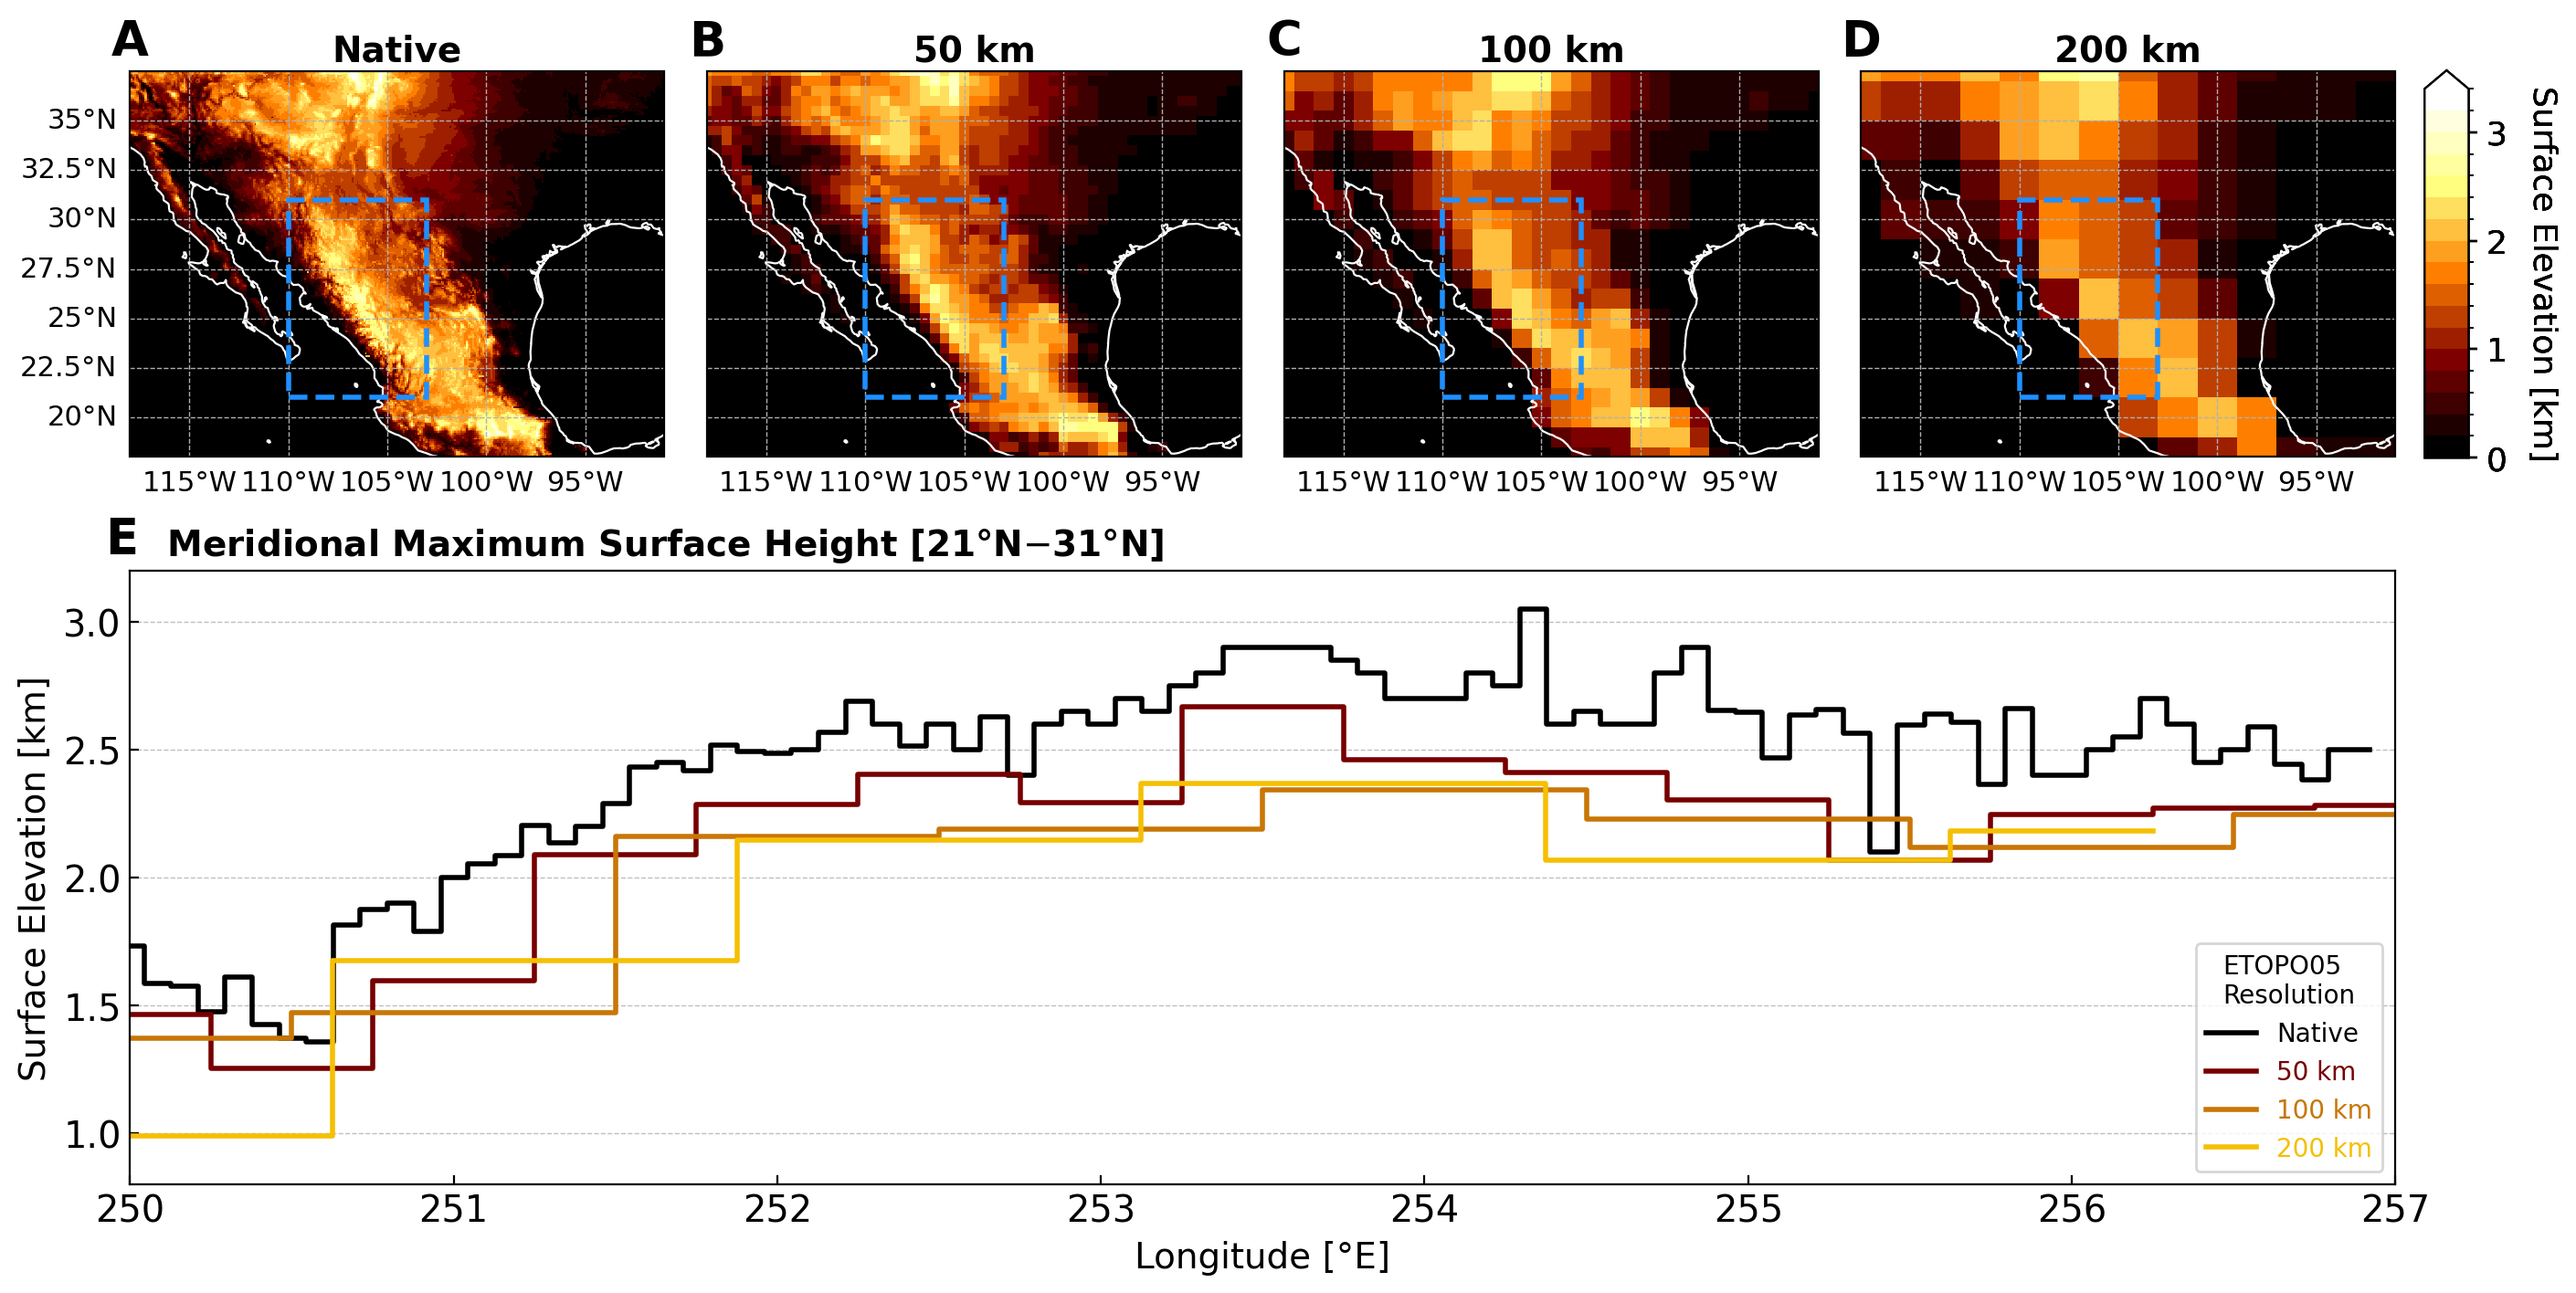

In [26]:
# --- settings ---
text_kw2  = {'size':19, 'weight':'bold', 'color':'k', 'ha':'center', 'va':'center'}
patch_kw  = {'ec':'dodgerblue', 'lw':2, 'ls':'--', 'fc':'none', 'clip_on':False, 'zorder':100}
tkw       = {'axis':'both', 'direction':'in', 'labelsize':'x-large'}
cmap      = cm.afmhot
levels    = np.linspace(0, 3400, 18)
norm      = mpl.colors.BoundaryNorm(levels, cmap.N)
trans     = ccrs.PlateCarree()
proj      = ccrs.PlateCarree()
map_bnds  = [-118., -91., 18., 37.5]

# --- layout ---
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.2, wspace=0.08, height_ratios=[1,1.5])
ax1 = fig.add_subplot(gs[0, 0], projection=proj)
ax2 = fig.add_subplot(gs[0, 1], projection=proj)
ax3 = fig.add_subplot(gs[0, 2], projection=proj)
ax4 = fig.add_subplot(gs[0, 3], projection=proj)
ax_p = fig.add_subplot(gs[1, :])

# --- map panels ---
datasets  = [topo_subset[key] for key in ['etopo','50km','100km','200km']]
titles    = ['Native', '50 km', '100 km', '200 km']
letters   = ['A', 'B', 'C', 'D']
axes_map  = [ax1, ax2, ax3, ax4]

for i, (ax, dat, title) in enumerate(zip(axes_map, datasets, titles)):
    ax.set_facecolor('k')
    cf = ax.pcolormesh(dat.lon, dat.lat, dat, cmap=cmap, norm=norm, shading='auto', transform=trans)
    ax.coastlines(color='white', linewidth=0.8)
    ax.set_extent(map_bnds, crs=trans)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=4)
    ax.text(-118, 39, letters[i], **text_kw2, transform=trans)
    # SMO box
    ax.add_patch(plt.Rectangle((-110, smo_ymin), smo_xmax-smo_xmin, smo_ymax-smo_ymin,
                               label='_Hidden', **patch_kw))
    gl = ax.gridlines(crs=trans, lw=0.5, colors='black', alpha=1.0, linestyle='--', draw_labels=True, zorder=10)
    gl.left_labels = (i == 0); gl.bottom_labels = True; gl.top_labels = False; gl.right_labels = False
    gl.xformatter=LongitudeFormatter()
    gl.yformatter=LatitudeFormatter()
    gl.xlabel_style = {'color':'black', 'weight':'normal', 'size':11}
    gl.ylabel_style = {'color':'black', 'weight':'normal', 'size':11}
    
    # shared colorbar
    cax = fig.add_axes([0.91, 0.6075, 0.015, 0.265])
    cbar = fig.colorbar(cf, cax=cax, extend='max', orientation='vertical')
    cbar.set_ticks([0, 1000, 2000, 3000])
    cbar.set_ticklabels([0, 1, 2, 3])
    cbar.set_label('Surface Elevation [km]', labelpad=20, rotation=270, size=13, fontweight='normal', ha='center')
    cbar.ax.tick_params(labelsize=13)
    for tick in cbar.ax.yaxis.get_major_ticks():
        tick.label1.set_fontweight('normal')

# --- profile plot ---
profile_colors = ['k', '#770001', '#C87606', '#F5BF03']
profile_labels = ['Native', '50 km', '100 km', '200 km']

for (key, prof), col, lbl in zip(smo_profile.items(), profile_colors, profile_labels):
    ax_p.step(prof.lon, prof.values, where='mid', color=col, lw=2, label=lbl)

ax_p.text(249.975, 3325, 'E', **text_kw2)
ax_p.set_title('   Meridional Maximum Surface Height [21°N$-$31°N]', loc='left', fontsize=14, fontweight='bold')
ax_p.set_xlabel('Longitude [°E]', fontsize=14, fontweight='normal')
ax_p.set_ylabel('Surface Elevation [km]', fontsize=14, fontweight='normal')
ax_p.set_xlim([smo_xmin, smo_xmax])
ax_p.set_ylim([800, 3200])
ax_p.set_yticks([1000, 1500, 2000, 2500, 3000])
ax_p.set_yticklabels([1.0, 1.5, 2.0, 2.5, 3.0])
ax_p.xaxis.set_tick_params(labelsize='x-large')
ax_p.yaxis.set_tick_params(labelsize='x-large')
ax_p.tick_params(**tkw)
#ax_p.grid(axis='x', lw=0.5, color='grey', alpha=0.5, linestyle='--')  # vertical only
ax_p.grid(axis='y', lw=0.5, color='grey', alpha=0.5, linestyle='--')  # horizontal only
ax_p.legend(title='ETOPO05\nResolution',
            prop={'size':10, 'weight':'normal'}, labelcolor='linecolor',
            loc='lower right', frameon=True)

plt.savefig('../figs/topo_idealized_smo_profiles.png', transparent=False, bbox_inches='tight', dpi=150)
plt.savefig('../figs/topo_idealized_smo_profiles.pdf', transparent=False, bbox_inches='tight')

## Supplemental figure of key geographic features

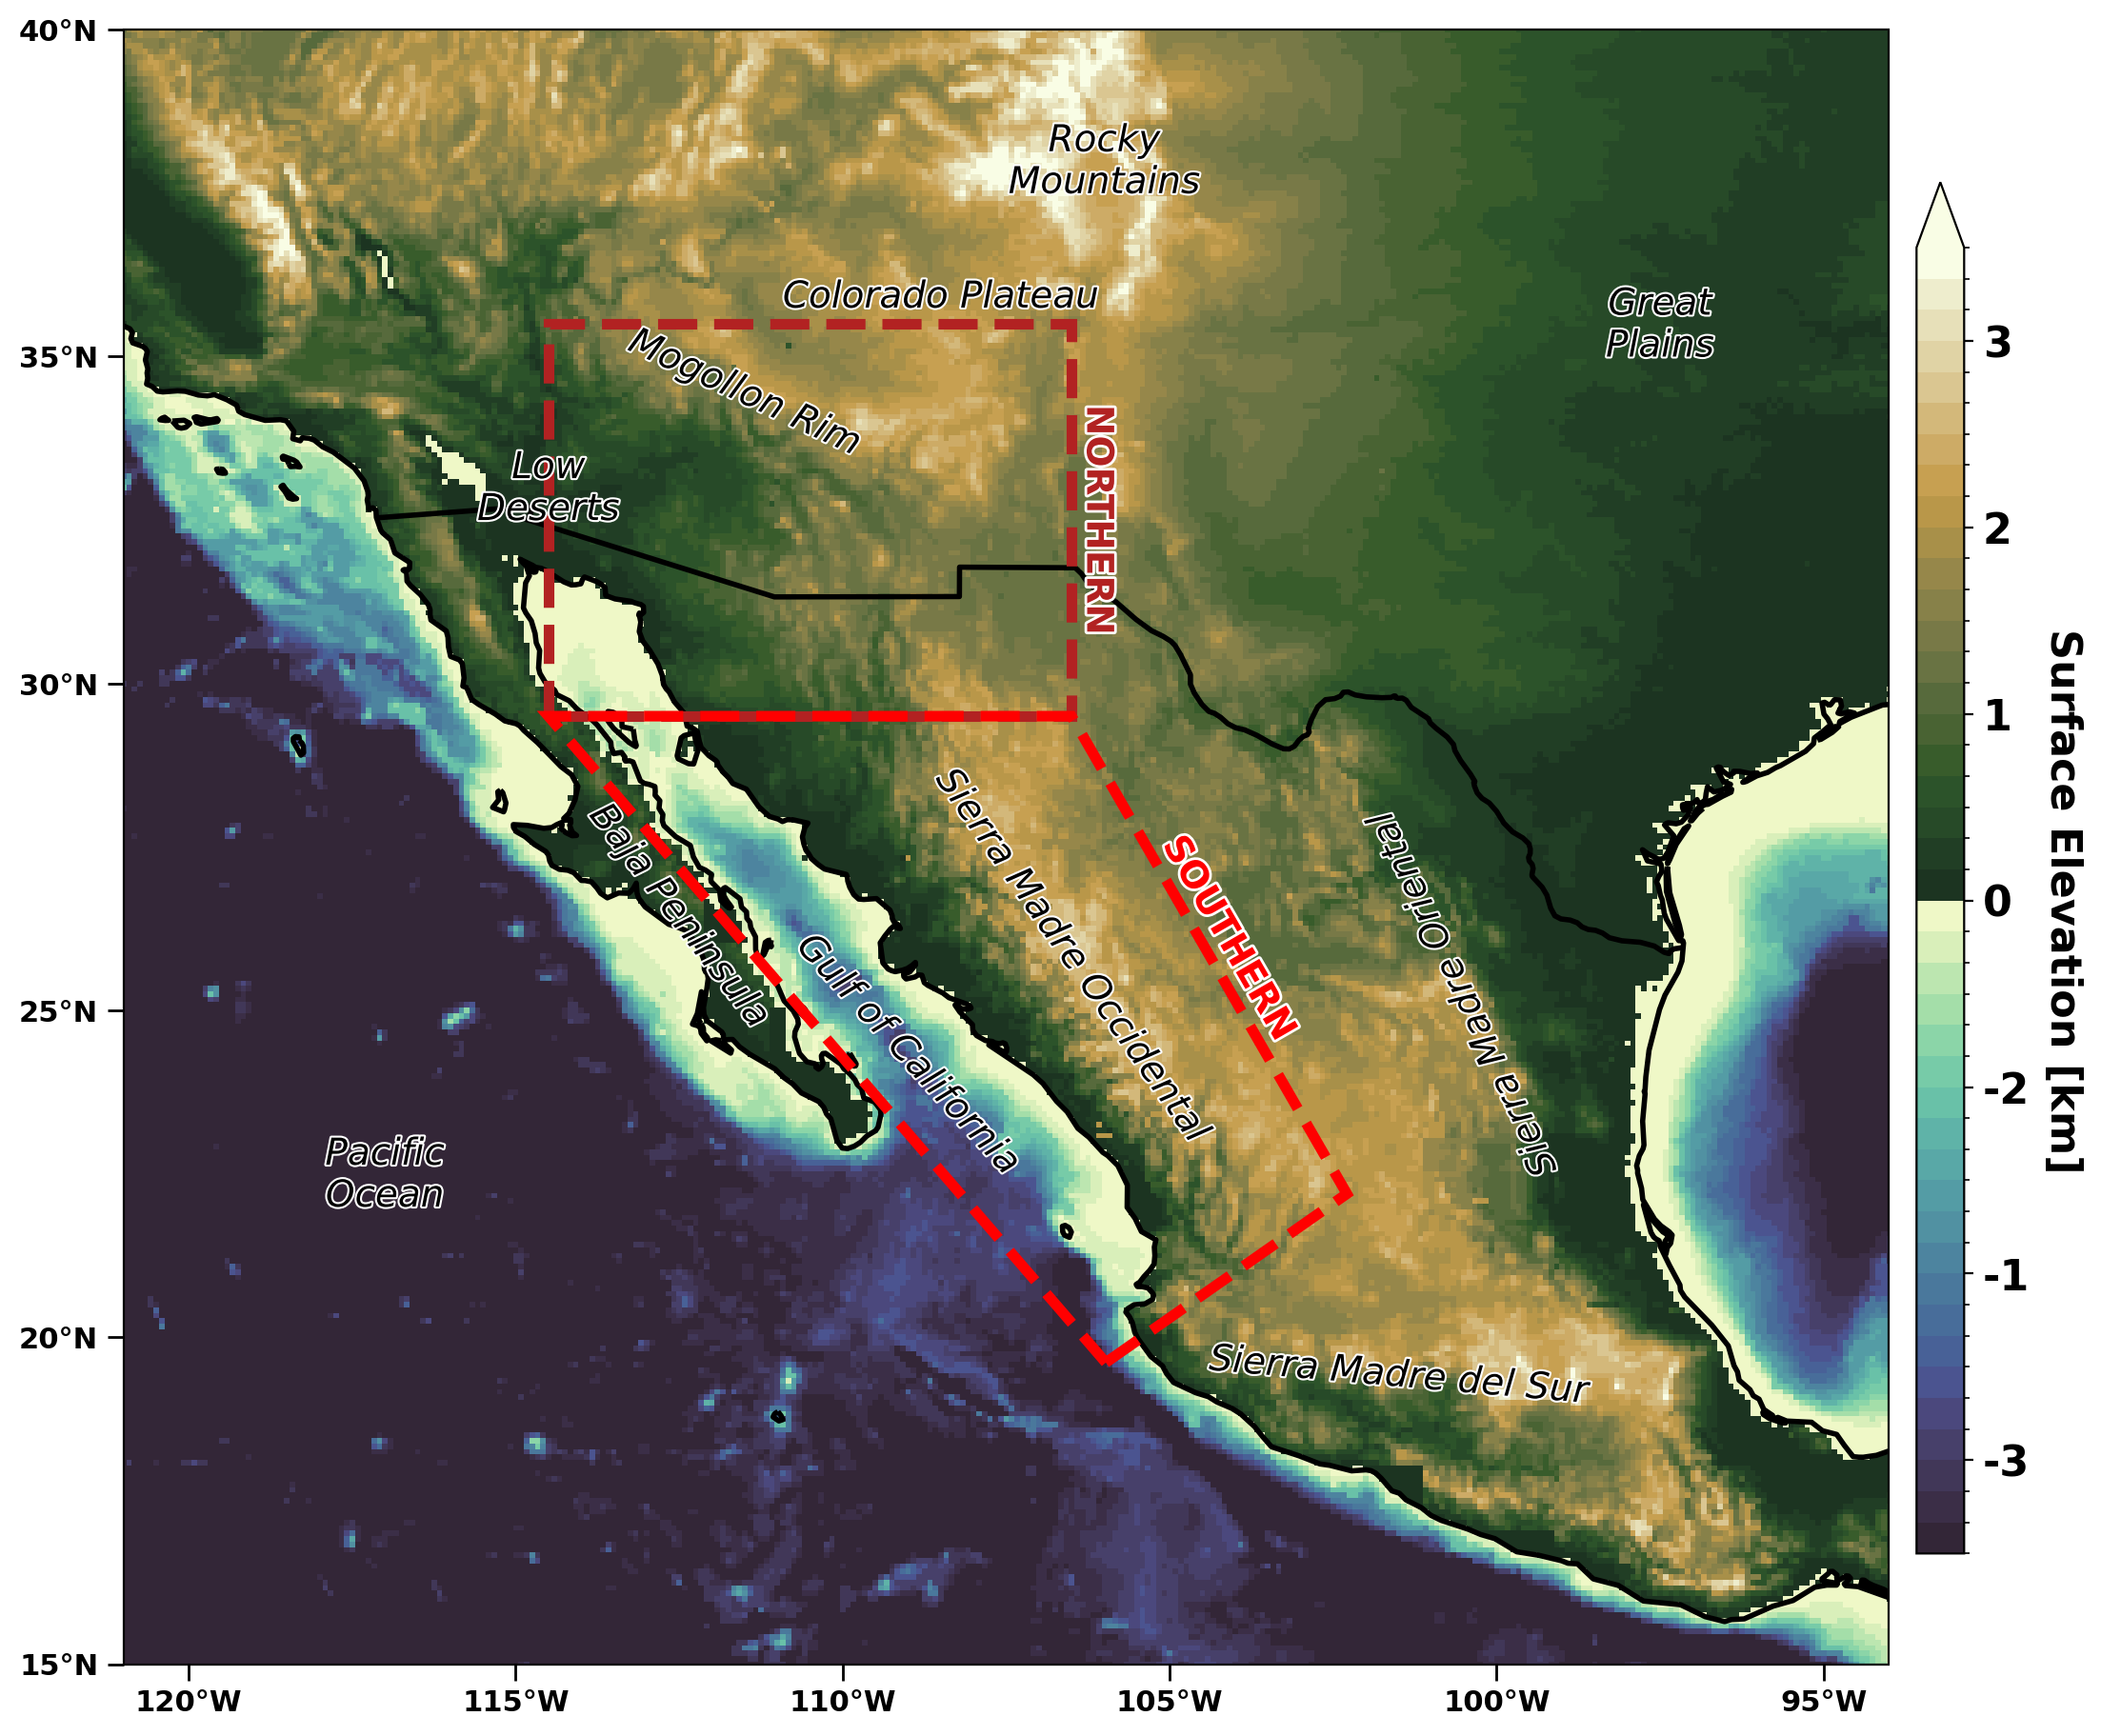

In [12]:
# --- settings --- #
patch_kw  = {'ec':'dodgerblue', 'lw':2, 'ls':'--', 'fc':'none', 'clip_on':False, 'zorder':90}
text_kw = {'ha':'center', 'color':'k', 'fontsize':14, 'fontweight':'light', 'fontstyle':'italic', 'fontname':'Bitstream Vera Sans', 'zorder':100}
cmap      = cmocean.tools.lighten(cmo.topo, 0.95)
levels    = np.linspace(-3500, 3500, 43)
norm      = mpl.colors.BoundaryNorm(levels, cmap.N)
trans     = ccrs.PlateCarree()
proj      = ccrs.PlateCarree()
map_bnds  = [-121., -94., 16., 39]

# --- layout --- #
fig, ax = plt.subplots(1, 1, figsize=(10, 9), layout='constrained', subplot_kw={'projection':proj})

cf = ax.pcolormesh(etopo_full.lon, etopo_full.lat, etopo_full, cmap=cmap, norm=norm, shading='nearest', transform=trans)

ax.coastlines(color='k', linewidth=2)
#ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
ax.set_extent(map_bnds, crs=trans)
#ax.set_title(title, fontsize=14, fontweight='bold', pad=4)

# --- sub-domain boxes --- #
poly1 = patches.Polygon(coords_map['north'], closed=True, ec='firebrick', fc='none', lw=4, ls='--',
                        transform=ccrs.PlateCarree(), zorder=100)
ax.add_patch(poly1)
poly2 = patches.Polygon(coords_map['south'], closed=True, ec='red', fc='none', lw=4, ls='--',
                        transform=ccrs.PlateCarree(), zorder=100)
ax.add_patch(poly2)
ax.text(-106.1, 32.5,'NORTHERN', ha='center', va='center', color='firebrick', rotation=270, fontsize=14, fontweight='bold').set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
ax.text(-104.1, 26.1,'SOUTHERN', ha='center', va='center', color='red', rotation=-60, fontsize=14, fontweight='bold').set_path_effects([pe.withStroke(linewidth=2, foreground='white')])

# --- geographic labels --- #
ax.text(-106, 37.5,'Rocky\nMountains', rotation=0, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-97.5, 35,'Great\nPlains', rotation=0, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-108.5, 35.75,'Colorado Plateau', rotation=0, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-111.5, 33.5,'Mogollon Rim', rotation=-25, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-114.5, 32.5,'Low\nDeserts', rotation=0, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-106.5, 23,'Sierra Madre Occidental', rotation=-55, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-100.5, 22.5,'Sierra Madre Oriental', rotation=115, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-101.5, 19,'Sierra Madre del Sur', rotation=-5, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-112.5, 24.75,'Baja Peninsula', rotation=-52.5, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-109, 22.5,'Gulf of California', rotation=-47.5, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
ax.text(-117, 22,'Pacific\nOcean', rotation=0, **text_kw).set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])

# --- formatting --- #
xticks = np.arange(-120, -90, 5)
yticks = np.arange(15, 41, 5)
ax.set_xticks(xticks, crs=proj)
ax.set_yticks(yticks, crs=proj)
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=6, width=1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    
# --- colorbar --- #
cax = fig.add_axes([1.0, 0.1, 0.025, 0.8])
cbar = fig.colorbar(cf, cax=cax, extend='max', orientation='vertical')
cbar.set_ticks([-3000, -1000, -2000, 0, 1000, 2000, 3000])
cbar.set_ticklabels([-3, -2, -1, 0, 1, 2, 3])
cbar.set_label('Surface Elevation [km]', labelpad=20, rotation=270, size=16, fontweight='bold', ha='center')
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('bold')

#plt.savefig('../figs/study_region_geographic_features.png', transparent=False, bbox_inches='tight', dpi=150)
#plt.savefig('../figs/study_region_geographic_features.pdf', transparent=False, bbox_inches='tight')